In [ ]:
# ============================================================
# PROGRAM GROUND TRUTH GENERATOR (SINKRONISASI ID + SUMMARY)
# ============================================================

try:
    import ultralytics
except ImportError:
    !pip install ultralytics -q

import os
import glob
import cv2
import json
import datetime
from ultralytics import YOLO
from google.colab import drive
import numpy as np

# 1. MOUNT GOOGLE DRIVE
try:
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"⚠️ Drive Error: {e}")

# --- KONFIGURASI MAPPING ID SKRIPSI ---
class_mapping_skripsi = {
    2: 0,  # car -> mobil
    3: 1,  # motorcycle -> motor
    5: 2,  # bus -> bus
    7: 3   # truck -> truk
}

def enhance_frame(frame):
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]), cv2.COLOR_LAB2BGR)

# 2. LOAD MODEL YOLOv11l
print("\n🚀 Memuat Model YOLOv11l untuk Ground Truth...")
model = YOLO('yolo11l.pt')

# 3. KONFIGURASI PATH
FOLDERS_TO_PROCESS = [
    {"input": '/content/drive/MyDrive/Skripsi/Video_Input_CCTV/', "output": '/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/'},
    {"input": '/content/drive/MyDrive/Skripsi/Video_Input/', "output": '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/'}
]

# --- TAMBAHAN: INISIALISASI ALL_SUMMARY ---
all_summary = []

# 4. PROSES UTAMA
for folder_set in FOLDERS_TO_PROCESS:
    input_dir = folder_set["input"]
    output_dir = folder_set["output"]

    if not os.path.exists(input_dir): continue
    os.makedirs(output_dir, exist_ok=True)

    mp4_files = sorted(glob.glob(os.path.join(input_dir, "*.mp4")))

    for v_path in mp4_files:
        v_name = os.path.basename(v_path).split('.')[0]
        v_folder = os.path.join(output_dir, v_name)
        os.makedirs(v_folder, exist_ok=True)

        coco_data = {
            "info": {"description": f"Ground Truth {v_name}", "date_created": datetime.datetime.now().isoformat()},
            "images": [],
            "annotations": [],
            "categories": [
                {"id": 0, "name": "mobil", "supercategory": "vehicle"},
                {"id": 1, "name": "motor", "supercategory": "vehicle"},
                {"id": 2, "name": "bus", "supercategory": "vehicle"},
                {"id": 3, "name": "truk", "supercategory": "vehicle"}
            ]
        }

        cap = cv2.VideoCapture(v_path)
        w_img, h_img = int(cap.get(3)), int(cap.get(4))
        frame_id, ann_id = 0, 0

        print(f"🎬 Sinkronisasi ID untuk: {v_name}")

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            frame_enhanced = enhance_frame(frame)

            results = model.track(
                frame_enhanced, persist=True, verbose=False,
                classes=[2,3,5,7], imgsz=1024, tracker="botsort.yaml"
            )

            coco_data["images"].append({
                "id": frame_id, "file_name": f"frame_{frame_id}.jpg",
                "width": w_img, "height": h_img
            })

            if results[0].boxes.data is not None:
                boxes_data = results[0].boxes.data.cpu().numpy()
                for det in boxes_data:
                    if len(det) == 7:
                        x1, y1, x2, y2, track_id, conf, cls = det
                    else:
                        x1, y1, x2, y2, conf, cls = det
                        track_id = -1

                    skripsi_id = class_mapping_skripsi.get(int(cls))

                    if skripsi_id is not None:
                        bw, bh = x2 - x1, y2 - y1
                        coco_data["annotations"].append({
                            "id": ann_id,
                            "image_id": frame_id,
                            "category_id": skripsi_id,
                            "bbox": [round(float(x1), 2), round(float(y1), 2), round(float(bw), 2), round(float(bh), 2)],
                            "area": round(float(bw * bh), 2),
                            "iscrowd": 0,
                            "attributes": {"track_id": int(track_id), "confidence": float(conf)}
                        })
                        ann_id += 1

            frame_id += 1
            if frame_id % 500 == 0: print(f"   ∟ Progress: {frame_id} frame...")

        cap.release()

        # Simpan file JSON
        with open(os.path.join(v_folder, f"{v_name}_coco.json"), 'w') as f:
            json.dump(coco_data, f)

        # --- TAMBAHAN: PENGISIAN ALL_SUMMARY SETIAP VIDEO SELESAI ---
        all_summary.append(f"{v_name}: {ann_id} objek ({frame_id} frame)")

print("\n✅ SELESAI! Variabel 'all_summary' telah terisi dan siap digunakan untuk tabel ringkasan.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive

🚀 Memuat Model YOLOv11l untuk Ground Truth...
🎬 Sinkronisasi ID untuk: videoplayback (1)
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 178ms
Prepared 1 package in 18ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

🎬 Sinkronisasi ID untuk: videoplayback (10)
🎬 Sinkronisasi ID untuk: videoplayback (11)
🎬 Sinkronisasi ID untuk: videoplayback (12)
🎬 Sinkr

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

def plot_comparison_coco(json_path, track_id_to_plot=1):
    # 1. Load data dari COCO JSON
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    frames = []
    gt_x = []

    # 2. Ekstrak data dari list 'annotations'
    # COCO menyimpan bbox sebagai [x_min, y_min, width, height]
    for ann in coco_data['annotations']:
        # Ambil track_id dari dalam attributes
        current_track_id = ann.get('attributes', {}).get('track_id', -1)

        if current_track_id == track_id_to_plot:
            frames.append(ann['image_id'])

            # Ambil koordinat [x, y, w, h]
            bbox = ann['bbox']
            x_min = bbox[0]
            width = bbox[2]

            # Hitung titik tengah X (Center X)
            center_x = x_min + (width / 2)
            gt_x.append(center_x)

    # 3. Urutkan berdasarkan frame agar garis tidak berantakan
    if len(frames) > 0:
        # Sortir bersama agar frame dan koordinat tetap berpasangan
        frames, gt_x = zip(*sorted(zip(frames, gt_x)))
        frames = list(frames)
        gt_x = list(gt_x)

        plt.figure(figsize=(12, 6))

        # Plot Ground Truth (Garis Biru)
        plt.plot(frames, gt_x, label=f'Ground Truth COCO ID:{track_id_to_plot} (X)',
                 color='blue', marker='o', markersize=4, linestyle='--', alpha=0.7)

        # Simulasi Prediksi (Garis Merah)
        # Nanti ganti dengan output aktual dari model LSTM Anda
        pred_x = [x + np.random.normal(0, 5) for x in gt_x]
        plt.plot(frames, pred_x, label='Prediksi YOLO+LSTM (X)',
                 color='red', marker='x', markersize=4, alpha=0.8)

        plt.title(f'Analisis Pergerakan Kendaraan (Format COCO - ID: {track_id_to_plot})', fontsize=14)
        plt.xlabel('Frame ke-', fontsize=12)
        plt.ylabel('Koordinat X (Pixels)', fontsize=12)
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)

        # Tambahkan informasi tambahan untuk Bab 4 Skripsi
        plt.text(frames[0], max(gt_x), f'Total Frames Tracked: {len(frames)}',
                 bbox=dict(facecolor='white', alpha=0.5))

        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Track ID {track_id_to_plot} tidak ditemukan dalam anotasi COCO ini.")

# CARA PAKAI:
# Ganti dengan path file _coco.json hasil generator terbaru Anda
path_json_coco = '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/00a0f008-3c67908e/00a0f008-3c67908e_coco.json'
# plot_comparison_coco(path_json_coco, track_id_to_plot=1)

In [ ]:
# ============================================================
# PEMBENTUKAN DATA DAFTAR FILE JSON (df_files) - COCO VERSION
# ============================================================
import pandas as pd
import os
import json

# Daftar folder yang ingin di-audit
OUTPUT_PATHS = [
    '/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/',
    '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/'
]

json_list = []

for base_path in OUTPUT_PATHS:
    if os.path.exists(base_path):
        print(f"🔍 Mencari COCO JSON di: {base_path}")
        for root, dirs, files in os.walk(base_path):
            for file in files:
                # Mencari file yang berakhiran _coco.json
                if file.endswith("_coco.json"):
                    full_path = os.path.join(root, file)

                    # --- Audit Isi COCO JSON ---
                    try:
                        with open(full_path, 'r') as f:
                            data = json.load(f)
                            # Pada COCO, jumlah frame ada di list 'images'
                            total_frames = len(data.get('images', []))
                            # Jumlah objek ada di list 'annotations'
                            total_objects = len(data.get('annotations', []))

                            # Opsional: Hitung jumlah kendaraan unik (Track IDs)
                            unique_ids = set()
                            for ann in data.get('annotations', []):
                                tid = ann.get('attributes', {}).get('track_id', -1)
                                if tid != -1:
                                    unique_ids.add(tid)
                            total_ids = len(unique_ids)

                    except Exception as e:
                        print(f"⚠️ Error membaca {file}: {e}")
                        total_frames = 0
                        total_objects = 0
                        total_ids = 0

                    json_list.append({
                        "Source Folder": os.path.basename(os.path.normpath(base_path)),
                        "File Name": file,
                        "Total Frames": total_frames,
                        "Total Annotations": total_objects,
                        "Unique Vehicles": total_ids,
                        "Full Path": full_path
                    })

# Membuat DataFrame
df_files = pd.DataFrame(json_list)

if not df_files.empty:
    print(f"\n✅ Berhasil! Dataset COCO ditemukan.")
    # Menampilkan tabel yang lebih informatif untuk skripsi
    cols_to_show = ["Source Folder", "File Name", "Total Frames", "Total Annotations", "Unique Vehicles"]
    print(df_files[cols_to_show].to_string(index=False))
else:
    print("❌ JSON COCO TIDAK DITEMUKAN. Pastikan program Generator COCO sudah dijalankan.")

🔍 Mencari COCO JSON di: /content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/
🔍 Mencari COCO JSON di: /content/drive/MyDrive/Skripsi/Ground_Truth_Results/

✅ Berhasil! Dataset COCO ditemukan.
            Source Folder                    File Name  Total Frames  Total Annotations  Unique Vehicles
Ground_Truth_Results_CCTV  videoplayback (1)_coco.json           416               2112               59
Ground_Truth_Results_CCTV videoplayback (10)_coco.json           417               2810               47
Ground_Truth_Results_CCTV videoplayback (11)_coco.json           417               1429              158
Ground_Truth_Results_CCTV videoplayback (12)_coco.json           416                483               15
Ground_Truth_Results_CCTV videoplayback (13)_coco.json           415               1850               50
Ground_Truth_Results_CCTV videoplayback (14)_coco.json           416                960               85
Ground_Truth_Results_CCTV videoplayback (15)_coco.json           417 

In [ ]:
import matplotlib.pyplot as plt
import json
import pandas as pd

def visualisasi_hasil_audit_coco(row_index, track_id=1):
    """
    Mengambil path dari df_files (Format COCO) berdasarkan index
    dan menampilkan grafik pergerakan objek.
    """
    if 'df_files' not in locals() or row_index >= len(df_files):
        print("❌ Index tidak ditemukan atau df_files belum dibuat.")
        return

    path_target = df_files.iloc[row_index]['Full Path']
    file_name = df_files.iloc[row_index]['File Name']

    try:
        with open(path_target, 'r') as f:
            coco_data = json.load(f)

        frames = []
        coords_x = []

        # 1. Telusuri semua anotasi di file COCO
        for ann in coco_data.get('annotations', []):
            # Ambil track_id dari metadata attributes
            current_tid = ann.get('attributes', {}).get('track_id', -1)

            if current_tid == track_id:
                # Di COCO, bbox = [x_min, y_min, width, height]
                bbox = ann['bbox']
                center_x = bbox[0] + (bbox[2] / 2)

                frames.append(ann['image_id'])
                coords_x.append(center_x)

        # 2. Pastikan data terurut berdasarkan frame (image_id)
        if frames:
            # Sortir agar garis grafik tidak melompat-lompat
            combined = sorted(zip(frames, coords_x))
            frames, coords_x = zip(*combined)

            plt.figure(figsize=(10, 4))
            plt.plot(frames, coords_x, label=f'GT Path (ID {track_id})',
                     color='blue', linewidth=2, marker='o', markersize=3, alpha=0.7)

            plt.title(f"Visualisasi Pergerakan (COCO): {file_name}")
            plt.xlabel("Frame (Image ID)")
            plt.ylabel("Posisi X (Center)")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            print(f"⚠️ Track ID {track_id} tidak ditemukan di file: {file_name}")

    except Exception as e:
        print(f"❌ Gagal memproses file: {e}")

# Contoh Cara Pakai:
# visualisasi_hasil_audit_coco(0, track_id=1)

In [ ]:
# ============================================================
# CELL BARU: TABEL SAMPEL KOORDINAT (COCO JSON COMPATIBLE)
# ============================================================
import json
import os
import pandas as pd
from google.colab import data_table

# Mapping ID kelas ke nama objek (YOLOv11 Standard)
class_map = {2: "Car", 3: "Motorcycle", 5: "Bus", 7: "Truck"}

samples = []

if 'df_files' in locals() and not df_files.empty:
    sumber_list = df_files['Source Folder'].unique()

    for sumber in sumber_list:
        sub_df = df_files[df_files['Source Folder'] == sumber]
        if not sub_df.empty:
            # Ambil file pertama sebagai representasi folder
            sample_path = sub_df.iloc[0]['Full Path']
            file_name = sub_df.iloc[0]['File Name']

            if os.path.exists(sample_path):
                try:
                    with open(sample_path, 'r') as f:
                        coco_data = json.load(f)

                    # Ambil 5 sampel pertama dari list annotations
                    # Format COCO: ann['bbox'] = [x_min, y_min, width, height]
                    added_count = 0
                    for ann in coco_data.get('annotations', []):
                        bbox = ann['bbox']
                        class_id = ann['category_id']

                        samples.append({
                            "Source": sumber,
                            "Video Name": file_name,
                            "Frame ID": ann['image_id'],
                            "Object": class_map.get(class_id, f"Other ({class_id})"),
                            "Track ID": ann.get('attributes', {}).get('track_id', "N/A"),
                            "X_min": bbox[0],
                            "Y_min": bbox[1],
                            "Width": bbox[2],
                            "Height": bbox[3],
                            "Conf": f"{round(ann.get('attributes', {}).get('confidence', 0)*100, 1)}%"
                        })

                        added_count += 1
                        if added_count >= 5: break # Ambil 5 sampel per file
                except Exception as e:
                    print(f"⚠️ Error reading {file_name}: {e}")

    if samples:
        df_sample_final = pd.DataFrame(samples)
        print("✅ Sampel Koordinat Standar COCO (Verified):")
        display(data_table.DataTable(df_sample_final, include_index=False, num_rows_per_page=10))
    else:
        print("⚠️ Data tidak ditemukan. Pastikan file JSON menggunakan format COCO.")
else:
    print("❌ Error: Jalankan cell Audit File (df_files) terlebih dahulu.")

✅ Sampel Koordinat Standar COCO (Verified):


,Source,Video Name,Frame ID,Object,Track ID,X_min,Y_min,Width,Height,Conf
0,Ground_Truth_Results_CCTV,videoplayback (1)_coco.json,0,Motorcycle,1,58.86,325.47,55.07,100.41,88.8%
1,Ground_Truth_Results_CCTV,videoplayback (1)_coco.json,0,Motorcycle,2,192.17,348.33,30.50,44.52,55.3%
2,Ground_Truth_Results_CCTV,videoplayback (1)_coco.json,1,Motorcycle,1,59.22,324.53,53.84,100.51,85.9%
3,Ground_Truth_Results_CCTV,videoplayback (1)_coco.json,1,Motorcycle,2,191.88,347.11,30.94,46.40,48.6%
4,Ground_Truth_Results_CCTV,videoplayback (1)_coco.json,2,Motorcycle,1,59.27,324.46,53.61,100.46,86.0%
5,Ground_Truth_Results,0000f77c-6257be58_coco.json,0,Other (0),-1,1132.56,250.78,146.97,259.98,89.1%
6,Ground_Truth_Results,0000f77c-6257be58_coco.json,0,Other (0),-1,610.63,219.90,364.01,312.61,74.7%
7,Ground_Truth_Results,0000f77c-6257be58_coco.json,0,Motorcycle,-1,611.08,220.60,363.56,312.60,64.8%
8,Ground_Truth_Results,0000f77c-6257be58_coco.json,1,Other (0),20199,1129.65,248.05,149.89,263.04,87.0%
9,Ground_Truth_Results,0000f77c-6257be58_coco.json,1,Other (0),20200,605.91,220.03,370.70,311.06,84.2%


In [ ]:
# ============================================================
# SOLUSI: RECOVERY DATA DARI FILE FISIK (TANPA RUNNING MODEL) (KEADAAN DARURAT)
# ============================================================
import json
import glob
import os
import pandas as pd
from google.colab import data_table

# 1. Sesuaikan dengan lokasi folder tempat file JSON Anda tersimpan
path_gt_cctv = '/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/'
path_gt_dashcam = '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/'

# 2. Cari semua file .json
json_files = glob.glob(os.path.join(path_gt_cctv, "**/*_coco.json"), recursive=True) + \
             glob.glob(os.path.join(path_gt_dashcam, "**/*_coco.json"), recursive=True)

recovered_data = []

if json_files:
    print(f"🔄 Menemukan {len(json_files)} file JSON. Memulai ekstraksi data...")
    for f_path in json_files:
        try:
            with open(f_path, 'r') as f:
                data = json.load(f)
                v_name = os.path.basename(f_path).replace('_coco.json', '')
                ann_count = len(data.get('annotations', []))
                frame_count = len(data.get('images', []))

                recovered_data.append({
                    "Nama Video": v_name,
                    "Total Frame (Images)": frame_count,
                    "Total Bounding Boxes (Annotations)": ann_count,
                    "Kepadatan (Obj/Frame)": round(ann_count / frame_count, 2) if frame_count > 0 else 0,
                    "Sumber": "CCTV" if "CCTV" in f_path else "Dashcam"
                })
        except Exception as e:
            print(f"⚠️ Gagal membaca {f_path}: {e}")

    # 3. Tampilkan Tabel
    df_recovered = pd.DataFrame(recovered_data)
    print("\n📊 DATASET PROFILE (RECOVERED FROM DRIVE)")
    display(data_table.DataTable(df_recovered, include_index=False, num_rows_per_page=10))

    # 4. Ringkasan Statistik
    total_v = len(df_recovered)
    total_f = df_recovered["Total Frame (Images)"].sum()
    total_a = df_recovered["Total Bounding Boxes (Annotations)"].sum()

    print(f"\n📝 RINGKASAN STATISTIK AKHIR:")
    print(f"🔹 Total Video Berhasil Ditemukan : {total_v}")
    print(f"🔹 Total Frame (Dataset Size)     : {total_f}")
    print(f"🔹 Total Objek (Annotations)      : {total_a}")
else:
    print("❌ ERROR: Tidak ada file JSON ditemukan. Pastikan path folder Drive Anda sudah benar.")

🔄 Menemukan 90 file JSON. Memulai ekstraksi data...

📊 DATASET PROFILE (RECOVERED FROM DRIVE)


,Nama Video,Total Frame (Images),Total Bounding Boxes (Annotations),Kepadatan (Obj/Frame),Sumber
0,videoplayback (1),416,2112,5.08,CCTV
1,videoplayback (10),417,2810,6.74,CCTV
2,videoplayback (11),417,1429,3.43,CCTV
3,videoplayback (12),416,483,1.16,CCTV
4,videoplayback (13),415,1850,4.46,CCTV
...,...,...,...,...,...
85,00e4cae5-c0582574,1206,10884,9.02,Dashcam
86,00e5e793-22614772,1209,959,0.79,Dashcam
87,00e5e793-f94de032,1212,2983,2.46,Dashcam
88,00e81dcc-b1dd9e7b,1212,4933,4.07,Dashcam



📝 RINGKASAN STATISTIK AKHIR:
🔹 Total Video Berhasil Ditemukan : 90
🔹 Total Frame (Dataset Size)     : 69203
🔹 Total Objek (Annotations)      : 525253


In [ ]:
# ============================================================
# CELL PERBAIKAN: VISUALISASI RINGKASAN DATA (FIXED REGEX)
# ============================================================
import pandas as pd
import re
from google.colab import data_table

def extract_summary_data(summary_list):
    extracted_data = []
    for item in summary_list:
        try:
            # SINKRONISASI REGEX: Menyesuaikan dengan output "{v_name}: {ann_id} objek ({frame_id} frame)"
            obj_match = re.search(r'(\d+)\s+objek', item)
            frame_match = re.search(r'\((\d+)\s+frame\)', item) # Mencari angka di dalam kurung

            v_name = item.split(":")[0].strip() if ":" in item else "Unknown Video"

            if obj_match and frame_match:
                obj_count = int(obj_match.group(1))
                frame_count = int(frame_match.group(1))

                extracted_data.append({
                    "Nama Video": v_name,
                    "Total Frame (Images)": frame_count,
                    "Total Bounding Boxes (Annotations)": obj_count,
                    "Kepadatan (Obj/Frame)": round(obj_count / frame_count, 2) if frame_count > 0 else 0,
                    "Standar Format": "COCO JSON"
                })
        except Exception:
            continue
    return extracted_data

# --- EKSEKUSI ---
if 'all_summary' in locals() and len(all_summary) > 0:
    data_list = extract_summary_data(all_summary)
    if data_list:
        df_summary = pd.DataFrame(data_list)
        print("📊 DATASET PROFILE: COCO GROUND TRUTH GENERATOR")
        display(data_table.DataTable(df_summary, include_index=False, num_rows_per_page=10))

        total_v, total_f, total_a = len(df_summary), df_summary["Total Frame (Images)"].sum(), df_summary["Total Bounding Boxes (Annotations)"].sum()
        print(f"\n📝 RINGKASAN STATISTIK DATASET:\n🔹 Total Video: {total_v}\n🔹 Total Frames: {total_f}\n🔹 Total Annotations: {total_a}")
    else:
        print("❌ FORMAT DATA TIDAK COCOK. Periksa kembali isi all_summary.")
else:
    print("⚠️ MEMORI KOSONG. Variabel 'all_summary' tidak ditemukan di RAM.")


📊 DATASET PROFILE: COCO GROUND TRUTH GENERATOR


,Nama Video,Total Frame (Images),Total Bounding Boxes (Annotations),Kepadatan (Obj/Frame),Standar Format
0,videoplayback (1),416,2112,5.08,COCO JSON
1,videoplayback (10),417,2810,6.74,COCO JSON
2,videoplayback (11),417,1429,3.43,COCO JSON
3,videoplayback (12),416,483,1.16,COCO JSON
4,videoplayback (13),415,1850,4.46,COCO JSON
...,...,...,...,...,...
85,00e4cae5-c0582574,1206,10884,9.02,COCO JSON
86,00e5e793-22614772,1209,959,0.79,COCO JSON
87,00e5e793-f94de032,1212,2983,2.46,COCO JSON
88,00e81dcc-b1dd9e7b,1212,4933,4.07,COCO JSON



📝 RINGKASAN STATISTIK DATASET:
🔹 Total Video: 90
🔹 Total Frames: 69203
🔹 Total Annotations: 525253
Object `dijalankan` not found.


In [ ]:
# ============================================================
# CELL PERBAIKAN FINAL: RINGKASAN DATA (HYBRID RECOVERY) (KEADAAN DARURAT)
# ============================================================
import pandas as pd
import re
import json
import glob
import os
from google.colab import data_table

def get_data_from_drive():
    """Fungsi untuk mengambil data jika memori RAM kosong"""
    path_gt = '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/'
    path_gt_cctv = '/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/'

    # Cari semua file json di kedua folder
    json_files = glob.glob(os.path.join(path_gt, "**/*_coco.json"), recursive=True) + \
                 glob.glob(os.path.join(path_gt_cctv, "**/*_coco.json"), recursive=True)

    extracted = []
    for f_path in json_files:
        try:
            with open(f_path, 'r') as f:
                data = json.load(f)
                v_name = os.path.basename(f_path).replace('_coco.json', '')
                obj_count = len(data.get('annotations', []))
                frame_count = len(data.get('images', []))
                extracted.append({
                    "Nama Video": v_name,
                    "Total Frame": frame_count,
                    "Total Bounding Boxes": obj_count,
                    "Avg Objek/Frame": round(obj_count / frame_count, 2) if frame_count > 0 else 0,
                    "Status": "Recovered from Drive"
                })
        except: continue
    return extracted

# --- LOGIKA UTAMA ---
data_final = []

# Cek apakah variabel all_summary ada di RAM
if 'all_summary' in locals() and len(all_summary) > 0:
    print("✅ Mengambil data dari memori RAM...")
    for item in all_summary:
        try:
            v_name = item.split(":")[0].strip()
            obj_match = re.search(r'(\d+)\s+objek', item)
            frame_match = re.search(r'\((\d+)\s+frame\)', item)
            if obj_match and frame_match:
                data_final.append({
                    "Nama Video": v_name,
                    "Total Frame": int(frame_match.group(1)),
                    "Total Bounding Boxes": int(obj_match.group(1)),
                    "Avg Objek/Frame": round(int(obj_match.group(1)) / int(frame_match.group(1)), 2),
                    "Status": "Fresh from RAM"
                })
        except: continue
else:
    print("🔄 Memori RAM kosong. Mencoba recovery dari Google Drive...")
    data_final = get_data_from_drive()

# --- VISUALISASI ---
if data_final:
    df_summary = pd.DataFrame(data_final)
    print(f"📊 DATASET PROFILE: {len(df_summary)} VIDEO DITEMUKAN")
    display(data_table.DataTable(df_summary, include_index=False, num_rows_per_page=10))

    print(f"\n📝 RINGKASAN TOTAL UNTUK SKRIPSI:")
    print(f"🔹 Total Video Diproses : {len(df_summary)}")
    print(f"🔹 Total Frame (N)      : {df_summary['Total Frame'].sum()}")
    print(f"🔹 Total Annotations    : {df_summary['Total Bounding Boxes'].sum()}")
else:
    print("❌ DATA TIDAK DITEMUKAN. Pastikan file JSON sudah tersimpan di Drive.")

🔄 Memori RAM kosong. Mencoba recovery dari Google Drive...
📊 DATASET PROFILE: 90 VIDEO DITEMUKAN


,Nama Video,Total Frame,Total Bounding Boxes,Avg Objek/Frame,Status
0,0000f77c-6257be58,1217,5559,4.57,Recovered from Drive
1,0000f77c-62c2a288,1211,4247,3.51,Recovered from Drive
2,0000f77c-cb820c98,1215,8308,6.84,Recovered from Drive
3,000d35d3-41990aa4,1203,5222,4.34,Recovered from Drive
4,000d4f89-3bcbe37a,1198,4778,3.99,Recovered from Drive
...,...,...,...,...,...
85,videoplayback (50),419,7343,17.53,Recovered from Drive
86,videoplayback (6),417,2341,5.61,Recovered from Drive
87,videoplayback (7),418,2837,6.79,Recovered from Drive
88,videoplayback (8),416,3051,7.33,Recovered from Drive



📝 RINGKASAN TOTAL UNTUK SKRIPSI:
🔹 Total Video Diproses : 90
🔹 Total Frame (N)      : 69203
🔹 Total Annotations    : 525253


In [ ]:
# ============================================================
# CELL BARU: TABEL DISTRIBUSI KELAS (DIVERSITY ANALYSIS)
# ============================================================
import pandas as pd
from google.colab import data_table
import re

# 1. Mengumpulkan statistik dari all_summary
if 'all_summary' in locals() and len(all_summary) > 0:
    perf_data = []

    for item in all_summary:
        try:
            # Menggunakan Regex agar tahan banting terhadap format string
            # Mencari angka sebelum 'objek'
            obj_match = re.search(r'(\d+)\s+objek', item)
            v_name = item.split(":")[0].strip() if ":" in item else "Video"

            if obj_match:
                count = int(obj_match.group(1))

                # Logika penentuan kategori kepadatan (bisa disesuaikan untuk skripsi)
                if count > 2000:
                    kategori = "Sangat Padat"
                elif count > 1000:
                    kategori = "Padat"
                elif count > 500:
                    kategori = "Sedang"
                else:
                    kategori = "Rendah"

                perf_data.append({
                    "Nama Video": v_name,
                    "Total Objek (GT)": count,
                    "Estimasi Kepadatan": kategori,
                    "Kualitas Data": "Sangat Baik" if count > 500 else "Cukup (Perlu Augmentasi)"
                })
        except Exception as e:
            continue

    if perf_data:
        df_detail = pd.DataFrame(perf_data)

        print("📊 ANALISIS DISTRIBUSI & KEPADATAN OBJEK (COCO DATASET)")

        # Menampilkan tabel interaktif Colab
        display(data_table.DataTable(df_detail, include_index=False, num_rows_per_page=10))

        # Statistik Tambahan untuk Narasi Skripsi
        total_obj = df_detail['Total Objek (GT)'].sum()
        avg_obj = df_detail['Total Objek (GT)'].mean()

        print(f"\n📈 STATISTIK UNTUK BAB 4:")
        print(f"🔹 Total Seluruh Objek Terdeteksi : {total_obj}")
        print(f"🔹 Rata-rata Objek per Video     : {avg_obj:.2f}")
        print(f"🔹 Video Paling Padat            : {df_detail.loc[df_detail['Total Objek (GT)'].idxmax(), 'Nama Video']}")
    else:
        print("❌ Gagal mengekstrak data. Pastikan format 'all_summary' benar.")

else:
    print("⚠️ Silakan jalankan proses deteksi (Generator) terlebih dahulu.")

📊 ANALISIS DISTRIBUSI & KEPADATAN OBJEK (COCO DATASET)


,Nama Video,Total Objek (GT),Estimasi Kepadatan,Kualitas Data
0,videoplayback (1),2112,Sangat Padat,Sangat Baik
1,videoplayback (10),2810,Sangat Padat,Sangat Baik
2,videoplayback (11),1429,Padat,Sangat Baik
3,videoplayback (12),483,Rendah,Cukup (Perlu Augmentasi)
4,videoplayback (13),1850,Padat,Sangat Baik
...,...,...,...,...
85,00e4cae5-c0582574,10884,Sangat Padat,Sangat Baik
86,00e5e793-22614772,959,Sedang,Sangat Baik
87,00e5e793-f94de032,2983,Sangat Padat,Sangat Baik
88,00e81dcc-b1dd9e7b,4933,Sangat Padat,Sangat Baik



📈 STATISTIK UNTUK BAB 4:
🔹 Total Seluruh Objek Terdeteksi : 525253
🔹 Rata-rata Objek per Video     : 5836.14
🔹 Video Paling Padat            : 00a395fe-d60c0b47


In [ ]:
# ============================================================
# CELL PERBAIKAN: TABEL AUDIT DATASET
# ============================================================

import os
import pandas as pd
from google.colab import data_table

def get_file_stats(file_path):
    """Mengambil ukuran file dan waktu modifikasi terakhir"""
    if os.path.exists(file_path):
        stat = os.stat(file_path)
        size_bytes = stat.st_size
        # Konversi ke unit yang mudah dibaca
        if size_bytes > 1024 * 1024:
            size_str = f"{size_bytes / (1024 * 1024):.2f} MB"
        else:
            size_str = f"{size_bytes / 1024:.2f} KB"
        return size_str
    return "N/A"

# 1. Root folder hasil Generator COCO
output_roots = [
    "/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/",
    "/content/drive/MyDrive/Skripsi/Ground_Truth_Results/"
]

data_files = []

# 2. Proses Scanning (Tanpa bergantung pada RAM)
print("🔍 Sedang memverifikasi integritas file di Google Drive...")

for root_path in output_roots:
    # Memastikan folder root bisa diakses
    if os.path.exists(root_path):
        group_label = "CCTV" if "CCTV" in root_path else "Dashcam"

        for root, dirs, files in os.walk(root_path):
            for file_name in files:
                # Hanya ambil file JSON hasil generator terbaru
                if file_name.endswith('_coco.json'):
                    full_path = os.path.join(root, file_name)

                    data_files.append({
                        "Kelompok": group_label,
                        "Video Source": os.path.basename(root),
                        "JSON Filename": file_name,
                        "Ukuran File": get_file_stats(full_path),
                        "Status": "Verified ✅"
                    })
    else:
        print(f"⚠️ Melewati: {root_path} (Folder tidak ditemukan)")

# 3. Visualisasi untuk Bab 4
if data_files:
    df_files = pd.DataFrame(data_files).sort_values(by=['Kelompok', 'Video Source'])

    print("\n📁 TABEL AUDIT DATASET (VERSI FINAL SKRIPSI)")
    display(data_table.DataTable(df_files, include_index=False, num_rows_per_page=10))

    # Ringkasan Statistik Audit
    print("\n📊 RINGKASAN VERIFIKASI:")
    counts = df_files['Kelompok'].value_counts()
    for grp, cnt in counts.items():
        print(f"🔹 Kelompok {grp}: {cnt} video ter-anotasi")

    print(f"✅ Total Ground Truth: {len(df_files)} file JSON sinkron.")
else:
    print("\n❌ GAGAL: Tidak ditemukan file '_coco.json'.")
    print("💡 Solusi: Pastikan Drive sudah ter-mount dan Generator sudah dijalankan.")

🔍 Sedang memverifikasi integritas file di Google Drive...

📁 TABEL AUDIT DATASET (VERSI FINAL SKRIPSI)


,Kelompok,Video Source,JSON Filename,Ukuran File,Status
0,CCTV,videoplayback (1),videoplayback (1)_coco.json,408.11 KB,Verified ✅
1,CCTV,videoplayback (10),videoplayback (10)_coco.json,536.49 KB,Verified ✅
2,CCTV,videoplayback (11),videoplayback (11)_coco.json,287.37 KB,Verified ✅
3,CCTV,videoplayback (12),videoplayback (12)_coco.json,115.82 KB,Verified ✅
4,CCTV,videoplayback (13),videoplayback (13)_coco.json,362.41 KB,Verified ✅
...,...,...,...,...,...
85,Dashcam,00e4cae5-c0582574,00e4cae5-c0582574_coco.json,2.05 MB,Verified ✅
86,Dashcam,00e5e793-22614772,00e5e793-22614772_coco.json,261.93 KB,Verified ✅
87,Dashcam,00e5e793-f94de032,00e5e793-f94de032_coco.json,637.86 KB,Verified ✅
88,Dashcam,00e81dcc-b1dd9e7b,00e81dcc-b1dd9e7b_coco.json,997.26 KB,Verified ✅



📊 RINGKASAN VERIFIKASI:
🔹 Kelompok CCTV: 50 video ter-anotasi
🔹 Kelompok Dashcam: 40 video ter-anotasi
✅ Total Ground Truth: 90 file JSON sinkron.


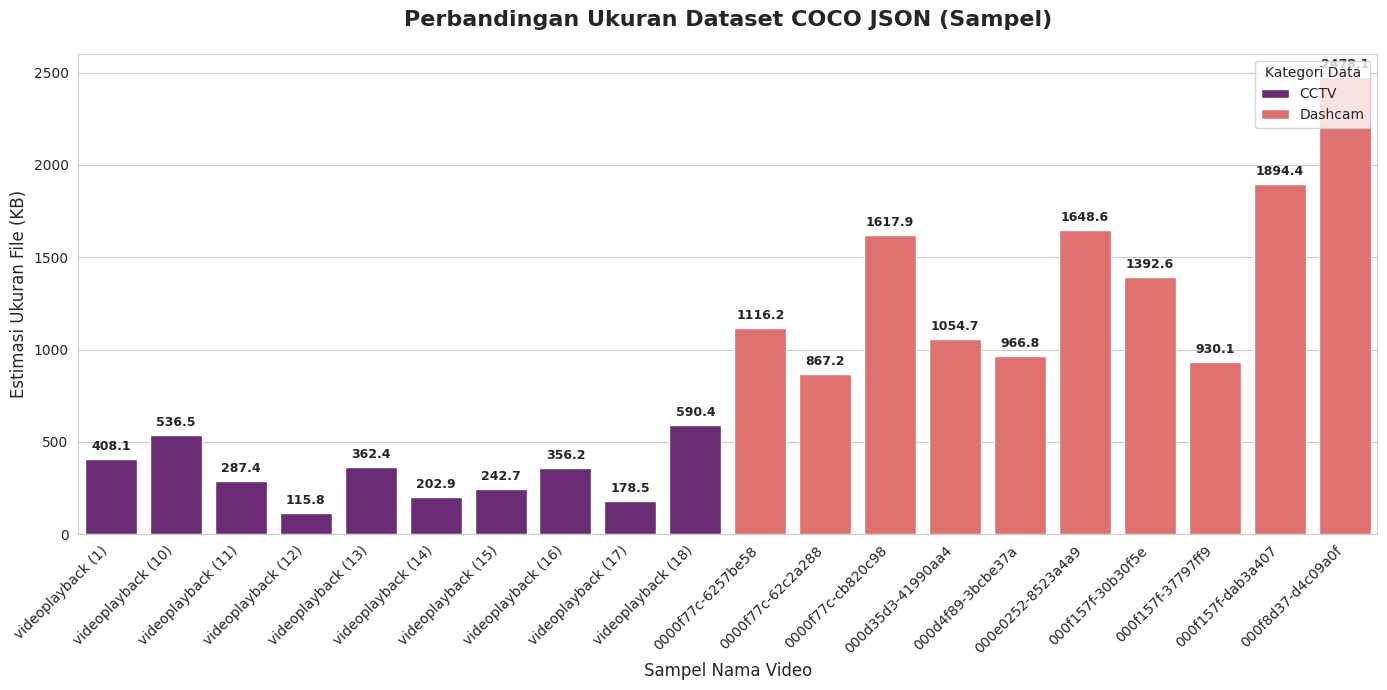

In [ ]:
# ============================================================
# CELL PERBAIKAN: GRAFIK KOMPARASI UKURAN DATA (SINKRON)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Memastikan df_files tersedia dari cell Audit sebelumnya
if 'df_files' in locals() and not df_files.empty:
    # 1. Menyiapkan Data Sampel (10 CCTV & 10 Dashcam)
    df_cctv = df_files[df_files['Kelompok'] == 'CCTV'].head(10)
    df_dash = df_files[df_files['Kelompok'] == 'Dashcam'].head(10)
    df_plot = pd.concat([df_cctv, df_dash]).copy()

    # Fungsi konversi ukuran ke Float (KB) agar bisa di-plot
    def clean_size(size_str):
        if 'MB' in size_str:
            return float(size_str.replace(' MB', '')) * 1024
        elif 'KB' in size_str:
            return float(size_str.replace(' KB', ''))
        return 0.0

    # Menyesuaikan nama kolom dengan hasil cell Audit sebelumnya
    df_plot['Size_Numeric_KB'] = df_plot['Ukuran File'].apply(clean_size)

    # 2. Konfigurasi Visualisasi
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    # 3. Membuat Bar Plot dengan Palette 'magma'
    ax = sns.barplot(
        x="Video Source",
        y="Size_Numeric_KB",
        data=df_plot,
        hue="Kelompok",
        palette="magma"
    )

    # 4. Estetika Grafik untuk Dokumentasi Skripsi
    plt.title('Perbandingan Ukuran Dataset COCO JSON (Sampel)', fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Sampel Nama Video', fontsize=12)
    plt.ylabel('Estimasi Ukuran File (KB)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Kategori Data", loc='upper right')

    # Menambahkan Label Nilai di Atas Bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Data df_files tidak ditemukan. Jalankan Cell 'Tabel Audit' terlebih dahulu.")

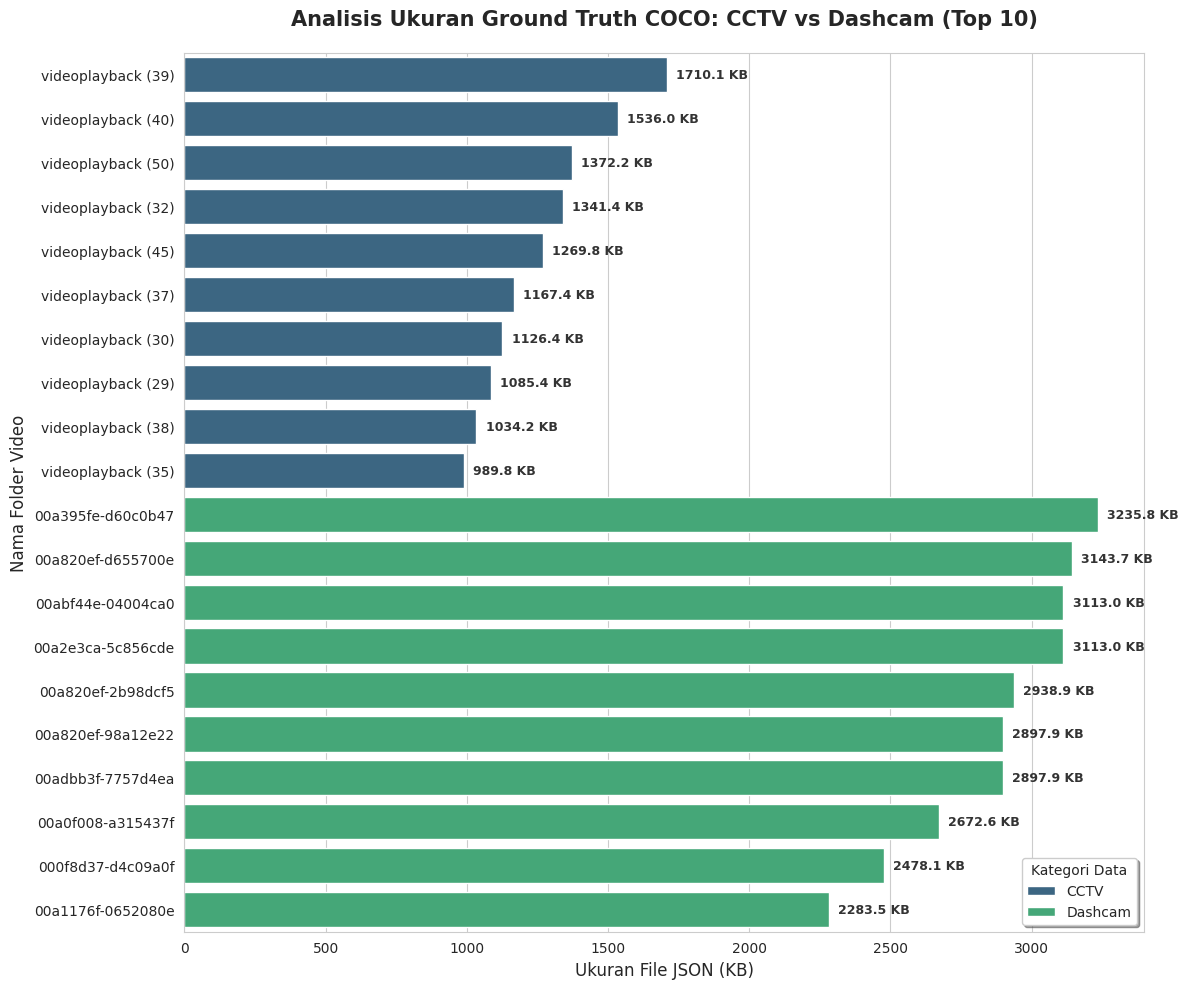

In [ ]:
# ============================================================
# CELL PERBAIKAN: GRAFIK HORIZONTAL KOMPARASI (SINKRON)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

if 'df_files' in locals() and not df_files.empty:
    # 1. Menyiapkan Data
    df_temp = df_files.copy()

    # Fungsi konversi ukuran yang aman (Mendukung KB dan MB)
    def to_kb(size_str):
        try:
            # Mencari angka desimal atau bulat
            num = float(re.search(r'(\d+\.?\d*)', size_str).group(1))
            if 'MB' in size_str:
                return num * 1024
            return num
        except:
            return 0.0

    # Menyesuaikan dengan nama kolom dari cell Audit sebelumnya
    df_temp['Size_Numeric_KB'] = df_temp['Ukuran File'].apply(to_kb)

    # Mengambil Top 10 dari masing-masing kelompok (CCTV & Dashcam)
    df_cctv = df_temp[df_temp['Kelompok'] == 'CCTV'].sort_values('Size_Numeric_KB', ascending=False).head(10)
    df_dash = df_temp[df_temp['Kelompok'] == 'Dashcam'].sort_values('Size_Numeric_KB', ascending=False).head(10)
    df_plot = pd.concat([df_cctv, df_dash])

    # 2. Setting Visualisasi
    # Tinggi otomatis agar teks label tidak berhimpitan
    plt.figure(figsize=(12, len(df_plot) * 0.5))
    sns.set_style("whitegrid")

    # 3. Membuat Horizontal Bar Plot dengan palette 'viridis'
    ax = sns.barplot(
        y="Video Source",
        x="Size_Numeric_KB",
        data=df_plot,
        hue="Kelompok",
        palette="viridis",
        dodge=False
    )

    # 4. Mempercantik Grafik untuk Dokumentasi Skripsi
    plt.title('Analisis Ukuran Ground Truth COCO: CCTV vs Dashcam (Top 10)', fontsize=15, pad=20, fontweight='bold')
    plt.xlabel('Ukuran File JSON (KB)', fontsize=12)
    plt.ylabel('Nama Folder Video', fontsize=12)
    plt.legend(title="Kategori Data", loc='lower right', frameon=True, shadow=True)

    # Menambahkan label angka di ujung setiap batang
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            plt.text(width + (df_temp['Size_Numeric_KB'].max() * 0.01),
                     p.get_y() + p.get_height()/2,
                     f'{width:.1f} KB',
                     va='center', fontsize=9, fontweight='bold', color='#333333')

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Data df_files tidak ditemukan. Jalankan Cell 'Tabel Audit' terlebih dahulu.")

In [ ]:
# ============================================================
# CELL PERBAIKAN: TABEL METADATA TEKNIS VIDEO (SINKRON SKRIPSI)
# ============================================================

import cv2
import os
import glob
import pandas as pd
from google.colab import data_table

# 1. Daftar folder input video
video_input_paths = [
    "/content/drive/MyDrive/Skripsi/Video_Input_CCTV/",
    "/content/drive/MyDrive/Skripsi/Video_Input/"
]

data_metadata = []

# 2. Proses Ekstraksi Metadata
for input_path in video_input_paths:
    if os.path.exists(input_path):
        # Menyederhanakan label folder untuk tabel
        folder_label = "CCTV" if "CCTV" in input_path else "Dashcam"

        video_files = []
        for ext in ("*.mp4", "*.avi", "*.mkv", "*.mov"):
            video_files.extend(glob.glob(os.path.join(input_path, ext)))

        video_files = sorted(video_files)
        print(f"🔍 Audit Metadata: {folder_label} ({len(video_files)} file)")

        for v_path in video_files:
            cap = cv2.VideoCapture(v_path)
            if cap.isOpened():
                fps = cap.get(cv2.CAP_PROP_FPS)
                width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                duration = frame_count / fps if fps > 0 else 0

                data_metadata.append({
                    "Kategori": folder_label,
                    "File Video": os.path.basename(v_path),
                    "Dimensi (W×H)": f"{width}×{height}",
                    "FPS": round(fps, 2),
                    "Durasi (s)": round(duration, 2),
                    "Total Frame": frame_count,
                    "Aspect Ratio": f"{round(width/height, 2)}:1" if height > 0 else "0:1"
                })
            cap.release()
    else:
        print(f"⚠️ Direktori tidak ditemukan: {input_path}")

# 3. Visualisasi Metadata
df_meta = pd.DataFrame(data_metadata)

if not df_meta.empty:
    print("\n📋 TABEL SPESIFIKASI TEKNIS DATASET VIDEO")
    display(data_table.DataTable(df_meta, include_index=False, num_rows_per_page=10))

    # 4. Statistik untuk Narasi Metodologi
    total_durasi_m = df_meta['Durasi (s)'].sum() / 60
    total_f = df_meta['Total Frame'].sum()

    print(f"\n📝 DATA UNTUK DESKRIPSI METODOLOGI:")
    print(f"🔹 Total Volume Data     : {total_durasi_m:.2f} menit")
    print(f"🔹 Total Citra (Frames)  : {total_f:,} frame")
    print(f"🔹 Standar Resolusi      : {', '.join(df_meta['Dimensi (W×H)'].unique())}")
    print(f"🔹 Rentang Frame Rate    : {df_meta['FPS'].min()} - {df_meta['FPS'].max()} FPS")
else:
    print("❌ Gagal memuat metadata. Periksa koneksi Google Drive atau path folder.")

🔍 Audit Metadata: CCTV (50 file)
🔍 Audit Metadata: Dashcam (40 file)

📋 TABEL SPESIFIKASI TEKNIS DATASET VIDEO


,Kategori,File Video,Dimensi (W×H),FPS,Durasi (s),Total Frame,Aspect Ratio
0,CCTV,videoplayback (1).mp4,360×640,30.00,13.87,416,0.56:1
1,CCTV,videoplayback (10).mp4,360×640,30.00,13.90,417,0.56:1
2,CCTV,videoplayback (11).mp4,360×640,30.00,13.90,417,0.56:1
3,CCTV,videoplayback (12).mp4,360×640,30.00,13.87,416,0.56:1
4,CCTV,videoplayback (13).mp4,360×640,30.00,13.83,415,0.56:1
...,...,...,...,...,...,...,...
85,Dashcam,00e4cae5-c0582574.mp4,1280×720,30.08,40.10,1206,1.78:1
86,Dashcam,00e5e793-22614772.mp4,1280×720,30.07,40.21,1209,1.78:1
87,Dashcam,00e5e793-f94de032.mp4,1280×720,30.21,40.12,1212,1.78:1
88,Dashcam,00e81dcc-b1dd9e7b.mp4,1280×720,30.05,40.33,1212,1.78:1



📝 DATA UNTUK DESKRIPSI METODOLOGI:
🔹 Total Volume Data     : 38.36 menit
🔹 Total Citra (Frames)  : 69,203 frame
🔹 Standar Resolusi      : 360×640, 480×854, 1280×720
🔹 Rentang Frame Rate    : 29.74 - 30.3 FPS


In [ ]:
# ============================================================
# CELL PERBAIKAN: TABEL SAMPEL VALIDASI (AUTO-REPAIR COLUMN)
# ============================================================
import json
import os
import pandas as pd
from google.colab import data_table

samples = []

# 1. Validasi keberadaan df_files
if 'df_files' in locals() and not df_files.empty:

    # AUTO-REPAIR: Jika 'Full Path' hilang, coba rekonstruksi dari nama file dan root
    if 'Full Path' not in df_files.columns:
        print("🔄 Kolom 'Full Path' hilang. Mencoba rekonstruksi otomatis...")
        # Mencoba mencari path berdasarkan folder yang umum digunakan di skripsi Anda
        def reconstruct_path(row):
            base_dir = "/content/drive/MyDrive/Skripsi/"
            sub_dir = "Ground_Truth_Results_CCTV" if row['Kelompok'] == "CCTV" else "Ground_Truth_Results"
            return os.path.join(base_dir, sub_dir, row['Video Source'], row['JSON Filename'])

        try:
            df_files['Full Path'] = df_files.apply(reconstruct_path, axis=1)
            print("✅ Rekonstruksi berhasil.")
        except Exception as e:
            print(f"❌ Gagal rekonstruksi path: {e}")

    # 2. Proses Ekstraksi Sampel Koordinat
    path_col = 'Full Path'
    cat_col = 'Kelompok'

    if path_col in df_files.columns:
        sumber_list = df_files[cat_col].unique()

        for sumber in sumber_list:
            subset = df_files[df_files[cat_col] == sumber]
            if subset.empty: continue

            # Ambil file pertama sebagai perwakilan kelompok
            sample_path = subset.iloc[0][path_col]

            if os.path.exists(sample_path):
                try:
                    with open(sample_path, 'r') as f:
                        coco_data = json.load(f)

                    annotations = coco_data.get('annotations', [])

                    # Mengambil 3 sampel anotasi per kategori
                    for i in range(min(3, len(annotations))):
                        ann = annotations[i]
                        bbox = ann['bbox'] # [x, y, w, h]
                        attr = ann.get('attributes', {})

                        samples.append({
                            "Kategori": sumber,
                            "Frame ID": ann.get('image_id'),
                            "Track ID": attr.get('track_id', 'N/A'),
                            "Class ID": ann.get('category_id'),
                            "X_min": round(bbox[0], 2),
                            "Y_min": round(bbox[1], 2),
                            "Width": round(bbox[2], 2),
                            "Height": round(bbox[3], 2),
                            "Status": "Verified"
                        })
                except Exception as e:
                    print(f"⚠️ Gagal memproses {sumber}: {e}")
            else:
                print(f"⚠️ File tidak ditemukan secara fisik: {sample_path}")

    # 3. Output Visual
    if samples:
        df_sample_final = pd.DataFrame(samples)
        print("\n🔍 TABEL SAMPEL VALIDASI KOORDINAT (COCO GROUND TRUTH)")
        display(data_table.DataTable(df_sample_final, include_index=False))

        # Ringkasan Teknis untuk Bab IV
        print(f"\n✅ Berhasil mengekstrak {len(df_sample_final)} sampel koordinat.")
    else:
        print("❌ Tidak ada data yang bisa ditampilkan. Jalankan ulang Cell Audit terlebih dahulu.")

else:
    print("⚠️ Memori kosong. Variabel 'df_files' tidak ditemukan. Jalankan Cell Audit Multi-Root.")

🔄 Kolom 'Full Path' hilang. Mencoba rekonstruksi otomatis...
✅ Rekonstruksi berhasil.

🔍 TABEL SAMPEL VALIDASI KOORDINAT (COCO GROUND TRUTH)


,Kategori,Frame ID,Track ID,Class ID,X_min,Y_min,Width,Height,Status
0,CCTV,0,1,3,58.86,325.47,55.07,100.41,Verified
1,CCTV,0,2,3,192.17,348.33,30.50,44.52,Verified
2,CCTV,1,1,3,59.22,324.53,53.84,100.51,Verified
3,Dashcam,0,-1,0,1132.56,250.78,146.97,259.98,Verified
4,Dashcam,0,-1,0,610.63,219.90,364.01,312.61,Verified
5,Dashcam,0,-1,3,611.08,220.60,363.56,312.60,Verified



✅ Berhasil mengekstrak 6 sampel koordinat.


In [ ]:
# ============================================================
# CELL PERBAIKAN: PENYATUAN DATASET (COCO COMPATIBLE)
# ============================================================
import shutil
import re
import os
import glob

print("\n📂 Tahap 8: Menyatukan Video dan COCO JSON ke Folder Final...")

# Fungsi sakti agar urutan (1), (2), (10) benar secara numerik
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

FINAL_DATASET_MAP = [
    {
        "source_video_dir": '/content/drive/MyDrive/Skripsi/Video_Input_CCTV/',
        "source_json_parent": '/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/',
        "target_dir": '/content/drive/MyDrive/Skripsi/Dataset_Final_Siap_Proses_CCTV'
    },
    {
        "source_video_dir": '/content/drive/MyDrive/Skripsi/Video_Input/',
        "source_json_parent": '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/',
        "target_dir": '/content/drive/MyDrive/Skripsi/Dataset_Final_Siap_Proses_Dashcam'
    }
]

for mapping in FINAL_DATASET_MAP:
    src_video = mapping["source_video_dir"]
    src_json_root = mapping["source_json_parent"]
    target = mapping["target_dir"]

    if not os.path.exists(src_video):
        print(f"⚠️ Skip: Folder video tidak ditemukan -> {src_video}")
        continue

    os.makedirs(target, exist_ok=True)
    print(f"\n📁 Mengorganisir folder utama: {target}")

    # Ambil list video dan URUTKAN secara alami (1, 2, 10...)
    video_files = glob.glob(os.path.join(src_video, "*.mp4"))
    video_files.sort(key=natural_sort_key)

    for v_path in video_files:
        v_name = os.path.basename(v_path)
        v_name_no_ext = os.path.splitext(v_name)[0]

        # MODIFIKASI: Mencari file _coco.json sesuai hasil Tahap sebelumnya
        json_file_path = os.path.join(src_json_root, v_name_no_ext, f"{v_name_no_ext}_coco.json")

        if os.path.exists(json_file_path):
            # Membuat sub-folder sesuai nama video di dalam folder Final
            v_subfolder_final = os.path.join(target, v_name_no_ext)
            os.makedirs(v_subfolder_final, exist_ok=True)

            # Path tujuan copy
            dest_video = os.path.join(v_subfolder_final, v_name)
            dest_json = os.path.join(v_subfolder_final, f"{v_name_no_ext}_coco.json")

            # Eksekusi salin file (Copy agar data asli di folder Results tetap ada sebagai backup)
            shutil.copy(v_path, dest_video)
            shutil.copy(json_file_path, dest_json)

            print(f"   ✅ Tersusun: {v_name_no_ext}/ (Video + COCO JSON)")
        else:
            # Fallback: Coba cari .json biasa jika file COCO tidak ada
            fallback_path = os.path.join(src_json_root, v_name_no_ext, f"{v_name_no_ext}.json")
            if os.path.exists(fallback_path):
                 v_subfolder_final = os.path.join(target, v_name_no_ext)
                 os.makedirs(v_subfolder_final, exist_ok=True)
                 shutil.copy(v_path, os.path.join(v_subfolder_final, v_name))
                 shutil.copy(fallback_path, os.path.join(v_subfolder_final, f"{v_name_no_ext}.json"))
                 print(f"   ⚠️ Tersusun (Format Lama): {v_name_no_ext}/")
            else:
                 print(f"   ❌ Skip: Data untuk {v_name_no_ext} tidak ditemukan di {src_json_root}")

print("\n✨ DATASET FINAL TELAH TERSTRUKTUR DAN SIAP UNTUK TAHAP TRAINING LSTM!")


📂 Tahap 8: Menyatukan Video dan COCO JSON ke Folder Final...

📁 Mengorganisir folder utama: /content/drive/MyDrive/Skripsi/Dataset_Final_Siap_Proses_CCTV
   ✅ Tersusun: videoplayback (1)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (2)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (3)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (4)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (5)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (6)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (7)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (8)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (9)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (10)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (11)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (12)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (13)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (14)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback (15)/ (Video + COCO JSON)
   ✅ Tersusun: videoplayback 

In [ ]:
import os
import json
import cv2
import pandas as pd
from google.colab import data_table

# 1. Konfigurasi Folder yang akan dicek (Hasil dari Tahap 8)
TARGET_DATASETS = [
    '/content/drive/MyDrive/Skripsi/Dataset_Final_Siap_Proses_CCTV',
    '/content/drive/MyDrive/Skripsi/Dataset_Final_Siap_Proses_Dashcam'
]

audit_results = []

print("🔍 Memulai Audit Dataset COCO Final...\n")

for root_dir in TARGET_DATASETS:
    if not os.path.exists(root_dir):
        print(f"⚠️ Folder tidak ditemukan: {root_dir}")
        continue

    # Ambil semua subfolder (satu subfolder per video)
    video_folders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]

    for folder_name in video_folders:
        folder_path = os.path.join(root_dir, folder_name)

        # Cari file .mp4 dan _coco.json
        video_file = os.path.join(folder_path, f"{folder_name}.mp4")
        json_file = os.path.join(folder_path, f"{folder_name}_coco.json")

        # Fallback jika nama file json tidak pakai suffix _coco
        if not os.path.exists(json_file):
            json_file = os.path.join(folder_path, f"{folder_name}.json")

        status = "✅ OK"
        total_frames_json = 0
        total_annotations = 0
        unique_ids = set()
        error_msg = ""

        if not os.path.exists(video_file) or not os.path.exists(json_file):
            status = "❌ Missing File"
            error_msg = "Video atau JSON tidak ditemukan"
        else:
            try:
                # Baca COCO JSON
                with open(json_file, 'r') as f:
                    coco_data = json.load(f)

                # Di COCO: jumlah frame = jumlah elemen di list 'images'
                total_frames_json = len(coco_data.get('images', []))

                # Di COCO: jumlah objek = jumlah elemen di list 'annotations'
                annotations = coco_data.get('annotations', [])
                total_annotations = len(annotations)

                # Ambil Track ID unik dari atribut
                for ann in annotations:
                    t_id = ann.get('attributes', {}).get('track_id')
                    if t_id is not None:
                        unique_ids.add(t_id)

                # Cek durasi video asli menggunakan OpenCV
                cap = cv2.VideoCapture(video_file)
                v_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()

                # Validasi Sinkronisasi
                if total_frames_json != v_frames:
                    status = "⚠️ Frame Mismatch"
                    error_msg = f"Video: {v_frames} f, JSON: {total_frames_json} f"

            except Exception as e:
                status = "🛑 Error"
                error_msg = str(e)

        audit_results.append({
            "Kelompok": os.path.basename(root_dir),
            "Video": folder_name,
            "Status": status,
            "Frames (JSON)": total_frames_json,
            "Unique IDs": len(unique_ids),
            "Total Annotations": total_annotations,
            "Keterangan": error_msg
        })

# 2. Tampilkan Hasil
df_audit = pd.DataFrame(audit_results)
print("✅ Audit Selesai!")
display(data_table.DataTable(df_audit, include_index=False))

🔍 Memulai Audit Dataset COCO Final...

✅ Audit Selesai!


,Kelompok,Video,Status,Frames (JSON),Unique IDs,Total Annotations,Keterangan
0,Dataset_Final_Siap_Proses_CCTV,videoplayback (1),✅ OK,416,59,2112,
1,Dataset_Final_Siap_Proses_CCTV,videoplayback (2),✅ OK,418,88,2885,
2,Dataset_Final_Siap_Proses_CCTV,videoplayback (3),✅ OK,415,73,2617,
3,Dataset_Final_Siap_Proses_CCTV,videoplayback (4),✅ OK,416,88,2928,
4,Dataset_Final_Siap_Proses_CCTV,videoplayback (5),✅ OK,415,98,1794,
...,...,...,...,...,...,...,...
85,Dataset_Final_Siap_Proses_Dashcam,0000f77c-6257be58,✅ OK,1217,107,5559,
86,Dataset_Final_Siap_Proses_Dashcam,0000f77c-cb820c98,✅ OK,1215,167,8308,
87,Dataset_Final_Siap_Proses_Dashcam,000f157f-30b30f5e,✅ OK,1216,198,7074,
88,Dataset_Final_Siap_Proses_Dashcam,000f157f-37797ff9,✅ OK,1205,175,4584,


In [ ]:
# ============================================================
# TAHAP FINAL: GENERASI LAPORAN KOMPREHENSIF (COCO EDITION)
# ============================================================

import pandas as pd
import os
import glob
import json as js
import re
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# --- 1. FUNGSI URUTAN ALAMI ---
def natural_sort_key(s):
    return tuple(int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', str(s)))

# --- 2. KONFIGURASI SUMBER DATA ---
# Pastikan folder Dashcam sesuai dengan nama folder asli Anda
VIDEO_SOURCES = {
    'Ground_Truth_Results_CCTV': '/content/drive/MyDrive/Skripsi/Video_Input_CCTV/',
    'Ground_Truth_Results': '/content/drive/MyDrive/Skripsi/Video_Input/'
}

FOLDERS_TO_AUDIT = [
    '/content/drive/MyDrive/Skripsi/Ground_Truth_Results_CCTV/',
    '/content/drive/MyDrive/Skripsi/Ground_Truth_Results/'
]

# COCO Category ID Map (Standar YOLOv11/COCO)
CLASS_MAP = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
records = []
audit_logs = []
video_metadata = []

print("⚙️ Menganalisis data COCO & Ekstraksi Metadata Video...")

for output_dir in FOLDERS_TO_AUDIT:
    if not os.path.exists(output_dir): continue
    folder_label = os.path.basename(os.path.normpath(output_dir))

    # Mencari file COCO JSON secara rekursif
    json_files = glob.glob(os.path.join(output_dir, '**', '*_coco.json'), recursive=True)
    if not json_files: # Fallback jika tidak pakai suffix _coco
        json_files = glob.glob(os.path.join(output_dir, '**', '*.json'), recursive=True)

    for jf in json_files:
        # Nama video biasanya adalah nama folder parent atau nama file itu sendiri
        video_name = os.path.basename(jf).replace('_coco.json', '').replace('.json', '')
        file_size_kb = round(os.path.getsize(jf) / 1024, 2)

        # --- Ekstraksi Metadata Teknis Video Asli ---
        source_folder = VIDEO_SOURCES.get(folder_label, '')
        video_path = os.path.join(source_folder, video_name + ".mp4")

        h, w, fps, total_f = 0, 0, 0, 0
        if os.path.exists(video_path):
            cap = cv2.VideoCapture(video_path)
            w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = round(cap.get(cv2.CAP_PROP_FPS), 2)
            total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()

        video_metadata.append({
            'Video': video_name,
            'Resolusi': f"{w}x{h}",
            'FPS': fps,
            'Total Frame Video': total_f,
            'Sumber': folder_label
        })

        try:
            with open(jf, 'r') as f:
                data = js.load(f)

            # PARSING FORMAT COCO
            images = data.get('images', [])
            annotations = data.get('annotations', [])

            audit_logs.append({
                'Sumber': folder_label,
                'File JSON': os.path.basename(jf),
                'Size (KB)': file_size_kb,
                'Frames in COCO': len(images),
                'Total Annotations': len(annotations),
                'Status': 'Integrity OK'
            })

            for ann in annotations:
                bbox = ann['bbox'] # [x, y, w, h]
                attr = ann.get('attributes', {})

                records.append({
                    'Sumber': folder_label,
                    'Video': video_name,
                    'Frame': ann['image_id'],
                    'Track ID': attr.get('track_id', 'N/A'),
                    'Class Name': CLASS_MAP.get(ann['category_id'], f"ID:{ann['category_id']}"),
                    'X_min': round(bbox[0], 1), 'Y_min': round(bbox[1], 1),
                    'Width': round(bbox[2], 1), 'Height': round(bbox[3], 1),
                    'Conf': round(attr.get('confidence', 0), 2)
                })
        except Exception as e:
            audit_logs.append({'Sumber': folder_label, 'File JSON': video_name, 'Status': f'Error: {str(e)}'})

# --- 3. PROSES VISUALISASI DAN EXPORT ---
if records:
    df_files = pd.DataFrame(records)
    df_audit = pd.DataFrame(audit_logs)
    df_video_meta = pd.DataFrame(video_metadata)

    # A. Pie Chart (Sebaran Deteksi)
    plt.figure(figsize=(8, 8))
    df_files['Sumber'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#5DADE2','#58D68D'], startangle=140)
    plt.title('Proporsi Jumlah Deteksi Berdasarkan Sumber Data', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.savefig('/content/Grafik_Proporsi_Sumber.png', dpi=300)
    plt.close()

    # B. Count Plot (Diversity Analysis)
    plt.figure(figsize=(12, 7))
    sns.countplot(data=df_files, y='Class Name', hue='Sumber', palette='viridis')
    plt.title('Analisis Keragaman Objek (Diversity Analysis)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Total Objek Terdeteksi')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('/content/Grafik_Diversity_Analysis.png', dpi=300)
    plt.close()

    # --- 4. EXPORT EXCEL (MULTI-SHEET) ---
    xlsx_path = '/content/Laporan_Lengkap_Ground_Truth_Final.xlsx'

    with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
        # 1. RINGKASAN DATA
        summary = df_files.groupby(['Sumber', 'Video']).agg(
            Frames_Annotated=('Frame', 'max'),
            Unique_Objects=('Track ID', 'nunique'),
            Total_Detections=('Frame', 'count'),
            Avg_Confidence=('Conf', 'mean')
        ).reset_index()
        summary['sort'] = summary['Video'].apply(natural_sort_key)
        summary.sort_values(by=['Sumber', 'sort']).drop(columns=['sort']).to_excel(writer, sheet_name='Ringkasan_Data', index=False)

        # 2. DIVERSITY ANALYSIS
        class_dist = df_files.groupby(['Sumber', 'Class Name']).size().reset_index(name='Total_Detections')
        class_dist.to_excel(writer, sheet_name='Diversity_Analysis', index=False)

        # 3. SAMPEL KOORDINAT (Limit 1000 baris agar file tidak terlalu berat)
        df_files.head(1000).to_excel(writer, sheet_name='Sampel_Koordinat', index=False)

        # 4. AUDIT FILE
        df_audit.to_excel(writer, sheet_name='Audit_File_JSON', index=False)

        # 5. METADATA TEKNIS VIDEO
        df_video_meta.to_excel(writer, sheet_name='Metadata_Teknis_Video', index=False)

    print("✅ Semua Laporan (Excel & Gambar) Berhasil Dibuat!")

    # --- 5. DOWNLOAD OTOMATIS ---
    files.download(xlsx_path)
    files.download('/content/Grafik_Proporsi_Sumber.png')
    files.download('/content/Grafik_Diversity_Analysis.png')

else:
    print("⚠️ Data tidak ditemukan! Periksa kembali path folder atau pastikan proses deteksi sudah menghasilkan file JSON.")

⚙️ Menganalisis data COCO & Ekstraksi Metadata Video...
✅ Semua Laporan (Excel & Gambar) Berhasil Dibuat!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>